# Scikit-HEP Tools
Think of `NumPy` and `CuPy` and `cuda.compute` as the raw muscles (the mathematical engines running on hardware). Think of `Scikit-HEP tools` as the brain (giving those numbers physical meaning, organizing them into histograms, and formatting them for physics publications). You use the engines to process raw arrays, and then pass the results into the HEP stack.

## 1. Physics Metadata & Constants (`particle` & `hepunits`)
Before processing millions of events, we need a reliable way to handle Physical Data Group (PDG) codes, decay metadata, and units without hardcoding Magic Numbers into their scripts.

`hepunits`: Enforces consistent scale management. Everything in Scikit-HEP internally defaults to `MeV` and `mm` (CLHEP/Geant4 standard).

`particle`: Direct Pythonic interface to the PDG particle data table.

In [1]:
pip install hepunits

In [2]:
pip install particle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.8/245.8 kB 6.5 MB/s eta 0:00:00


In [4]:
from hepunits import GeV, MeV, picosecond
from particle import Particle

# 1. Enforcing explicit units over hardcoded values
b_mass_limit = 5.279 * GeV
print(f"B0 Mass in default units (MeV): {b_mass_limit}")

# 2. Querying particle properties programmatically by PDG ID or name
p = Particle.from_pdgid(211)  # pi+
print(f"Particle: {p.name} | Mass: {p.mass} MeV | Charge: {p.charge}")

# Find all stable beauty hadrons
b_hadrons = Particle.findall(lambda x: x.lifetime > 1 * picosecond and "b" in x.quarks.lower())
b_hadrons

B0 Mass in default units (MeV): 5279.0
Particle: pi+ | Mass: 139.57039 MeV | Charge: 1


[<Particle: name="B0", pdgid=511, mass=5279.72 ± 0.08 MeV>,
 <Particle: name="B~0", pdgid=-511, mass=5279.72 ± 0.08 MeV>,
 <Particle: name="B+", pdgid=521, mass=5279.41 ± 0.07 MeV>,
 <Particle: name="B-", pdgid=-521, mass=5279.41 ± 0.07 MeV>,
 <Particle: name="B(s)0", pdgid=531, mass=5366.93 ± 0.10 MeV>,
 <Particle: name="B(s)~0", pdgid=-531, mass=5366.93 ± 0.10 MeV>,
 <Particle: name="Lambda(b)0", pdgid=5122, mass=5619.57 ± 0.16 MeV>,
 <Particle: name="Lambda(b)~0", pdgid=-5122, mass=5619.57 ± 0.16 MeV>,
 <Particle: name="Xi(b)-", pdgid=5132, mass=5797.0 ± 0.4 MeV>,
 <Particle: name="Xi(b)~+", pdgid=-5132, mass=5797.0 ± 0.4 MeV>,
 <Particle: name="Xi(b)0", pdgid=5232, mass=5791.7 ± 0.4 MeV>,
 <Particle: name="Xi(b)~0", pdgid=-5232, mass=5791.7 ± 0.4 MeV>,
 <Particle: name="Omega(b)-", pdgid=5332, mass=6045.8 ± 0.8 MeV>,
 <Particle: name="Omega(b)~+", pdgid=-5332, mass=6045.8 ± 0.8 MeV>]

In [ ]:
p.latex_name

#### 5-Minute Exercise: The Relativistic Transverse Momentum Challenge
**The Scenario:** You have tracked a series of highly energetic pions flying out of a collision vertex. You have their total momentum ($p$) and their angle relative to the beamline ($\theta$, polar angle).

**Your Tasks:**
- Look up the true mass of a charged pion ($\pi^+$) using particle.
- Convert that mass into default HEP units using hepunits.
- Compute the relativistic energy ($E = \sqrt{p^2 + m^2}$) and the transverse momentum ($p_T = p \cdot \sin\theta$) for all particles at once.Fill a high-performance hist.
- Hist object with the computed $p_T$ values.

```python
import hist
import numpy as np
from hepunits import GeV
from particle import Particle

# --- STEP 1 & 2: Physics Metadata Setup ---
# 1. TODO: Fetch the pi+ particle object using its PDG ID (211)
pion = ...
# 2. TODO: Extract its mass and ensure it is explicitly scaled to MeV
m_pion = ...

print(f"Target Particle: {pion.name} | Mass: {m_pion:.2f} MeV")

# Simulated experimental tracking data (1 million events)
# Momentum 'p' in MeV, Polar Angle 'theta' in radians
p_data = np.random.exponential(scale=30 * GeV, size=1_000_000)
theta_data = np.random.uniform(0.1, np.pi - 0.1, size=1_000_000)

# --- STEP 3: Vectorized Execution Engine (NumPy or CuPy) ---
# 3. TODO: Calculate p_T completely vectorized (No Python loops!)
# Hint: p_T = p * sin(theta)
pt_data = ...

# --- STEP 4: High-Performance Histogram Distribution ---
# 4. TODO: Define a regular histogram axis (50 bins from 0 to 100 GeV)
#    and fill it with your computed pt_data.
h = hist.Hist(
    hist.axis.Regular(..., name="pt", label=r"$p_T$ [GeV]"),
)
# Fill the histogram container
# h.fill(...)

print(f"Successfully binned {h.sum()} particle entries!")
```

In [10]:
pip install hist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.7 MB/s eta 0:00:00


In [12]:
import hist
import numpy as np
from hepunits import GeV
from particle import Particle

# --- STEP 1 & 2: Physics Metadata Setup ---
# 1. TODO: Fetch the pi+ particle object using its PDG ID (211)
pion = Particle.from_pdgid(211)
# 2. TODO: Extract its mass and ensure it is explicitly scaled to MeV
m_pion = pion.mass  # Already in MeV by default in particle package

print(f"Target Particle: {pion.name} | Mass: {m_pion:.2f} MeV")

# Simulated experimental tracking data (1 million events)
# Momentum 'p' in MeV, Polar Angle 'theta' in radians
p_data = np.random.exponential(scale=30 * GeV, size=1_000_000)
theta_data = np.random.uniform(0.1, np.pi - 0.1, size=1_000_000)

# --- STEP 3: Vectorized Execution Engine (NumPy or CuPy) ---
# 3. TODO: Calculate p_T completely vectorized (No Python loops!)
# Hint: p_T = p * sin(theta)
pt_data = p_data * np.sin(theta_data)

# --- STEP 4: High-Performance Histogram Distribution ---
# 4. TODO: Define a regular histogram axis (50 bins from 0 to 100 GeV)
#    and fill it with your computed pt_data.
h = hist.Hist(
    hist.axis.Regular(50, 0, 100 * GeV, name="pt", label=r"$p_T$ [GeV]"),
)
# Fill the histogram container
h.fill(pt_data)

h.show()
print(f"Successfully binned {h.sum()} particle entries!")

Target Particle: pi+ | Mass: 139.57 MeV
  0.000 _ x 10^+05                                                 122082/row ╷
  0.020 _██████████████████████████████████████████████████████████████████████
  0.040 _█████████████████████████████████████████████████████████
  0.060 _████████████████████████████████████████████████
  0.080 _████████████████████████████████████████
  0.100 _███████████████████████████████████
  0.120 _██████████████████████████████
  0.140 _███████████████████████████
  0.160 _████████████████████████
  0.180 _█████████████████████
  0.200 _███████████████████
  0.220 _█████████████████
  0.240 _███████████████
  0.260 _██████████████
  0.280 _████████████
  0.300 _███████████
  0.320 _██████████
  0.340 _█████████
  0.360 _████████
  0.380 _███████
  0.400 _███████
  0.420 _██████
  0.440 _██████
  0.460 _█████
  0.480 _█████
  0.500 _████
  0.520 _████
  0.540 _███
  0.560 _███
  0.580 _███
  0.600 _███
  0.620 _██
  0.640 _██
  0.660 _██
  0.680 _██
  0.700 _

<details>
<summary><b>Click to reveal the 5-Minute "The Relativistic Transverse Momentum Challenge"</b></summary>
The Correct Answer:

```python
# --- SOLUTIONS ---
# 1 & 2:
pion = Particle.from_pdgid(211)
m_pion = pion.mass  # Already in MeV by default in particle package

# 3:
pt_data = p_data * np.sin(theta_data)

# 4:
h = hist.Hist(hist.axis.Regular(50, 0, 100 * GeV, name="pt", label=r"$p_T$ [MeV]"))
h.fill(pt=pt_data)

## 2. High-Performance Histogramming (`hist`)
A common mistake is trying to bin millions of entries using `matplotlib.pyplot.hist` or `numpy.histogram`. For HEP scaling, this is a performance trap.

`hist` (built on top of C++ boost-histogram) shifts the mental model: histograms are treated as containers of data with named axes, not just visual plots. They support fast fill operations, storage types (like tracking weight variances), and can be sliced like standard arrays.

In [13]:
import hist
import numpy as np

h = hist.Hist(
    hist.axis.Regular(50, 0, 150, name="pt", label=r"$p_T$ [GeV]"),
    hist.axis.StrCategory(["signal", "background"], name="dataset"),
)

# Simulate streaming event data injections
mock_pt = np.random.normal(91.2, 10, size=100_000)

h.fill(pt=mock_pt, dataset="signal")

# Slicing & Projections work perfectly now using the new key
pt_signal_only = h[{"dataset": "signal"}]

print("Successfully allocated and sliced the multi-dimensional histogram!")
pt_signal_only

Successfully allocated and sliced the multi-dimensional histogram!


Hist(Regular(50, 0, 150, name='pt', label='$p_T$ [GeV]'), storage=Double()) # Sum: 100000.0

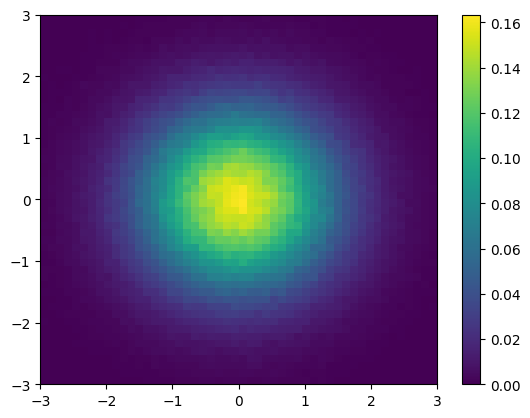

In [15]:
import functools
import operator

import matplotlib.pyplot as plt
import numpy as np

import hist

# Make a 2D histogram
hist2d = hist.Hist(hist.axis.Regular(50, -3, 3), hist.axis.Regular(50, -3, 3))

# Fill with Gaussian random values
hist2d.fill(np.random.normal(size=1_000_000), np.random.normal(size=1_000_000))

# Compute the areas of each bin
areas = functools.reduce(operator.mul, hist2d.axes.widths)

# Compute the density
density = hist2d.values() / hist2d.sum() / areas

# Make the plot
fig, ax = plt.subplots()
mesh = ax.pcolormesh(*hist2d.axes.edges.T, density.T)
fig.colorbar(mesh)
#plt.savefig("simple_density.png")